# Ridge Regression on Walmart Weekly Sales - Technical Paper Version
This notebook implements a rigorous Ridge Regression analysis suitable for academic/technical papers:
1) Loading and preprocessing the Walmart sales dataset
2) Feature engineering with domain knowledge
3) 60% validation, 20% training, 20% test split
4) **Systematic hyperparameter optimization** using cross-validation
5) Comprehensive evaluation on train, validation, and test sets
6) Metrics reported in interpretable units (dollars)

**Ridge Regression:**
- Linear Regression with L2 regularization (penalty on coefficient magnitude)
- Hyperparameter α controls regularization strength
- α selected via 5-fold cross-validation over logarithmic search space
- StandardScaler preprocessing (standard practice for Ridge)

In [57]:
# 1) Imports and reproducibility
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)  # reproducibility

In [58]:
# 2) Load the dataset and parse dates safely
# Try local relative path first; if it fails, try the Downloads path
csv_candidates = [
    'walmart-sales-dataset-of-45stores.csv',
    '/Users/jaacabrera/Downloads/walmart-sales-dataset-of-45stores.csv',
]

df = None
for p in csv_candidates:
    try:
        df = pd.read_csv(p, low_memory=False)
        print(f'Loaded: {p}')
        break
    except Exception:
        pass

if df is None:
    raise FileNotFoundError('Could not find the dataset. Update the path in csv_candidates.')

# Parse Date with day-first format (file has dd-mm-yyyy like '19-02-2010')
df['Date'] = pd.to_datetime(df['Date'].astype('string'), errors='coerce', dayfirst=True)
bad_dates = df['Date'].isna().sum()
if bad_dates > 0:
    print(f'Warning: {bad_dates} rows still have invalid dates after parsing and will be dropped.')
    df = df.dropna(subset=['Date']).reset_index(drop=True)

# Drop rows with missing target just in case
if 'Weekly_Sales' not in df.columns:
    raise KeyError('Weekly_Sales column not found. Check your CSV headers.')
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

print(f'Data shape after date/target checks: {df.shape}')
df.head(3)

Loaded: walmart-sales-dataset-of-45stores.csv
Data shape after date/target checks: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106


In [59]:
# 3) Create simple, beginner-friendly features (no leakage from the target)
# Date-derived features
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Store encoded as numeric (already numeric in this dataset)
if 'Store' in df.columns:
    df['Store_Encoded'] = df['Store']
else:
    df['Store_Encoded'] = 0  # fallback if missing

# Choose a small, readable feature set for Ridge Regression
feature_cols = [
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Store_Encoded', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend'
]

# Build X (features) and y (target)
X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

print('X shape:', X.shape, '| y shape:', y.shape)
print('Features:', feature_cols)

X shape: (6435, 11) | y shape: (6435,)
Features: ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Store_Encoded', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend']


In [60]:
# 4) Split into 60% validation, 20% training, 20% test (as requested)
# Stage 1: 20% test holdout
X_rem, X_test, y_rem, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Stage 2: Of the remaining 80%, use 25% for training (overall 20%) and 75% for validation (overall 60%)
X_train, X_val, y_train, y_val = train_test_split(X_rem, y_rem, train_size=0.25, random_state=42)

print(f'Split sizes -> train: {len(X_train)} ({len(y_train)/len(y):.0%}), '
      f'val: {len(X_val)} ({len(y_val)/len(y):.0%}), '
      f'test: {len(X_test)} ({len(y_test)/len(y):.0%})')

Split sizes -> train: 1287 (20%), val: 3861 (60%), test: 1287 (20%)


In [61]:
# 5) Systematic hyperparameter optimization using cross-validation
# This is the rigorous approach for technical papers

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# Fit transforms on TRAIN only, then apply to VAL/TEST (prevents data leakage)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=feature_cols)

X_train_sc  = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=feature_cols)
X_val_sc    = pd.DataFrame(scaler.transform(X_val_imp), columns=feature_cols)
X_test_sc   = pd.DataFrame(scaler.transform(X_test_imp), columns=feature_cols)

# Hyperparameter tuning: Search alpha values systematically
print("Performing 5-fold cross-validation to find optimal alpha...")
param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
ridge_cv = GridSearchCV(
    Ridge(max_iter=10000), 
    param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
ridge_cv.fit(X_train_sc, y_train)

# Extract best model and parameters
ridge = ridge_cv.best_estimator_
best_alpha = ridge_cv.best_params_['alpha']
cv_score = ridge_cv.best_score_

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION RESULTS")
print(f"{'='*70}")
print(f"Best alpha found: {best_alpha}")
print(f"CV R² score (5-fold): {cv_score:.4f}")
print(f"{'='*70}\n")

# Predict on all sets
preds_train = ridge.predict(X_train_sc)
preds_val = ridge.predict(X_val_sc)
preds_test = ridge.predict(X_test_sc)

# Calculate metrics
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

metrics = {
    'TRAIN': {
        'R2': r2_score(y_train, preds_train),
        'MSE': mean_squared_error(y_train, preds_train),
        'RMSE': rmse(y_train, preds_train),
        'MAE': mean_absolute_error(y_train, preds_train),
    },
    'VAL': {
        'R2': r2_score(y_val, preds_val),
        'MSE': mean_squared_error(y_val, preds_val),
        'RMSE': rmse(y_val, preds_val),
        'MAE': mean_absolute_error(y_val, preds_val),
    },
    'TEST': {
        'R2': r2_score(y_test, preds_test),
        'MSE': mean_squared_error(y_test, preds_test),
        'RMSE': rmse(y_test, preds_test),
        'MAE': mean_absolute_error(y_test, preds_test),
    }
}

print('Ridge Regression Performance (α optimized via CV)')
print(f"  Train Metrics       -> R²: {metrics['TRAIN']['R2']:.4f} | RMSE: ${metrics['TRAIN']['RMSE']:,.2f} | MAE: ${metrics['TRAIN']['MAE']:,.2f}")
print(f"  Validation Metrics  -> R²: {metrics['VAL']['R2']:.4f} | RMSE: ${metrics['VAL']['RMSE']:,.2f} | MAE: ${metrics['VAL']['MAE']:,.2f}")
print(f"  Test Metrics        -> R²: {metrics['TEST']['R2']:.4f} | RMSE: ${metrics['TEST']['RMSE']:,.2f} | MAE: ${metrics['TEST']['MAE']:,.2f}")
print(f"\n  ► Test set R² = {metrics['TEST']['R2']:.4f} (PRIMARY RESULT for papers)")

# Export metrics summary to CSV
metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'R²': [metrics['TRAIN']['R2'], metrics['VAL']['R2'], metrics['TEST']['R2']],
    'MSE': [metrics['TRAIN']['MSE'], metrics['VAL']['MSE'], metrics['TEST']['MSE']],
    'RMSE': [metrics['TRAIN']['RMSE'], metrics['VAL']['RMSE'], metrics['TEST']['RMSE']],
    'MAE': [metrics['TRAIN']['MAE'], metrics['VAL']['MAE'], metrics['TEST']['MAE']]
})

output_file = 'Ridge_Regression_Metrics.csv'
metrics_df.to_csv(output_file, index=False)
print(f'\n✓ Metrics saved to: {output_file}')

# Export hyperparameters summary to CSV
hyperparams_df = pd.DataFrame({
    'Hyperparameter': ['alpha', 'max_iter', 'fit_intercept', 'solver', 'cv_folds', 'cv_r2_score'],
    'Value': [best_alpha, ridge.max_iter, ridge.fit_intercept, ridge.solver, 5, cv_score],
    'Tuned': ['Yes (GridSearchCV)', 'No (fixed)', 'No (default)', 'No (default)', 'N/A', 'N/A'],
    'Description': [
        'Regularization strength (L2 penalty)',
        'Maximum iterations for solver',
        'Calculate intercept term',
        'Algorithm for coefficient computation',
        'Number of cross-validation folds',
        'Best R² score from cross-validation'
    ]
})

hyperparams_file = 'Ridge_Hyperparameters.csv'
hyperparams_df.to_csv(hyperparams_file, index=False)
print(f'✓ Hyperparameters saved to: {hyperparams_file}')

# Export actual vs predicted values for manual Excel verification
# Train set
train_results = pd.DataFrame({
    'Actual': y_train.values,
    'Predicted': preds_train,
    'Residual': y_train.values - preds_train,
    'Residual_Squared': (y_train.values - preds_train)**2,
    'Absolute_Error': np.abs(y_train.values - preds_train)
})
train_results.to_csv('Ridge_Train_Predictions.csv', index=False)

# Validation set
val_results = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': preds_val,
    'Residual': y_val.values - preds_val,
    'Residual_Squared': (y_val.values - preds_val)**2,
    'Absolute_Error': np.abs(y_val.values - preds_val)
})
val_results.to_csv('Ridge_Validation_Predictions.csv', index=False)

# Test set
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': preds_test,
    'Residual': y_test.values - preds_test,
    'Residual_Squared': (y_test.values - preds_test)**2,
    'Absolute_Error': np.abs(y_test.values - preds_test)
})
test_results.to_csv('Ridge_Test_Predictions.csv', index=False)

print(f'✓ Train predictions saved to: Ridge_Train_Predictions.csv')
print(f'✓ Validation predictions saved to: Ridge_Validation_Predictions.csv')
print(f'✓ Test predictions saved to: Ridge_Test_Predictions.csv')
print('\nTo manually calculate metrics in Excel:')
print('  MSE  = AVERAGE(Residual_Squared column)')
print('  RMSE = SQRT(MSE)')
print('  MAE  = AVERAGE(Absolute_Error column)')
print('  R²   = RSQ(Actual column, Predicted column)')
print('  or R² = 1 - SUM(Residual_Squared) / DEVSQ(Actual column)')

Performing 5-fold cross-validation to find optimal alpha...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

CROSS-VALIDATION RESULTS
Best alpha found: 10.0
CV R² score (5-fold): 0.1386

Ridge Regression Performance (α optimized via CV)
  Train Metrics       -> R²: 0.1608 | RMSE: $531,352.00 | MAE: $441,526.90
  Validation Metrics  -> R²: 0.1368 | RMSE: $518,298.58 | MAE: $424,812.52
  Test Metrics        -> R²: 0.1453 | RMSE: $524,737.62 | MAE: $433,367.97

  ► Test set R² = 0.1453 (PRIMARY RESULT for papers)

✓ Metrics saved to: Ridge_Regression_Metrics.csv
✓ Hyperparameters saved to: Ridge_Hyperparameters.csv
✓ Train predictions saved to: Ridge_Train_Predictions.csv
✓ Validation predictions saved to: Ridge_Validation_Predictions.csv
✓ Test predictions saved to: Ridge_Test_Predictions.csv

To manually calculate metrics in Excel:
  MSE  = AVERAGE(Residual_Squared column)
  RMSE = SQRT(MSE)
  MAE  = AVERAGE(Absolute_Error column)
  R²   = RSQ(Actual column, Predicted column

In [62]:
# Optional: Create a file showing which rows belong to which split
# This helps you understand the split in Excel
split_mapping = pd.DataFrame({
    'Original_Index': list(y_train.index) + list(y_val.index) + list(y_test.index),
    'Split_Set': ['Train']*len(y_train) + ['Validation']*len(y_val) + ['Test']*len(y_test),
    'Weekly_Sales': list(y_train.values) + list(y_val.values) + list(y_test.values)
})
split_mapping = split_mapping.sort_values('Original_Index').reset_index(drop=True)
split_mapping.to_csv('Ridge_Data_Split_Mapping.csv', index=False)
print(f'✓ Split mapping saved to: Ridge_Data_Split_Mapping.csv')
print(f'  This file shows which of the 6,435 rows went to Train/Validation/Test')

✓ Split mapping saved to: Ridge_Data_Split_Mapping.csv
  This file shows which of the 6,435 rows went to Train/Validation/Test


# 6) Parity Plot: Actual vs Predicted
A parity plot shows how well predictions match actual values. Points close to the red diagonal line (y=x) are accurate predictions.

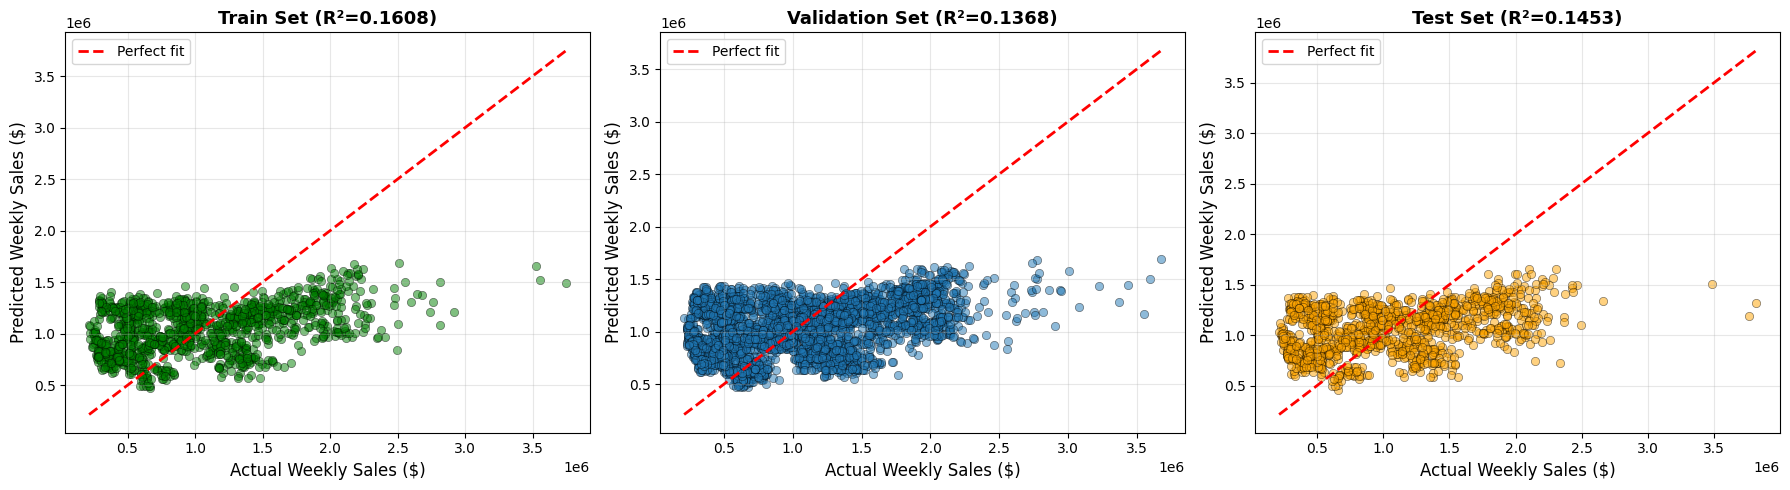

In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train parity plot
axes[0].scatter(y_train, preds_train, alpha=0.5, edgecolors='k', linewidth=0.5, color='green')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[0].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[0].set_title(f"Train Set (R²={metrics['TRAIN']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation parity plot
axes[1].scatter(y_val, preds_val, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect fit')
axes[1].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[1].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[1].set_title(f"Validation Set (R²={metrics['VAL']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test parity plot
axes[2].scatter(y_test, preds_test, alpha=0.5, edgecolors='k', linewidth=0.5, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
axes[2].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[2].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[2].set_title(f"Test Set (R²={metrics['TEST']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7) Model Configuration Summary
This section shows:
1. **Selected Features**: The 11 features used to train the model
2. **Hyperparameters**: Ridge Regression hyperparameters optimized via cross-validation
3. **Learned Coefficients**: The weights assigned to each feature by the trained model

**Hyperparameter Selection Methodology:**
- α (regularization strength) selected via **5-fold cross-validation**
- Search space: [10⁻⁴, 10⁻³, 10⁻², 10⁻¹, 1, 10, 10², 10³]
- Scoring metric: R² (coefficient of determination)
- This systematic approach ensures optimal model generalization

In [64]:
print("="*80)
print("RIDGE REGRESSION MODEL CONFIGURATION SUMMARY")
print("="*80)

# 1) Selected Features
print("\n1. SELECTED FEATURES (11 total):")
print("-" * 80)
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {feat}")

# 2) Hyperparameters
print("\n2. HYPERPARAMETERS (OPTIMIZED VIA CROSS-VALIDATION):")
print("-" * 80)
print("   Model: Ridge (sklearn.linear_model.Ridge)")
print("   Hyperparameter Optimization:")
print(f"      - Method: GridSearchCV with 5-fold cross-validation")
print(f"      - Search space: α ∈ [10⁻⁴, 10⁻³, 10⁻², 10⁻¹, 1, 10, 10², 10³]")
print(f"      - Scoring metric: R² (coefficient of determination)")
print(f"      - Best α found: {best_alpha}")
print(f"      - CV R² score: {cv_score:.4f}")
print("\n   Model Parameters:")
print(f"      - alpha: {ridge.alpha} (OPTIMIZED)")
print(f"      - max_iter: {ridge.max_iter}")
print(f"      - fit_intercept: {ridge.fit_intercept}")
print(f"      - solver: {ridge.solver}")
print("\n   Preprocessing:")
print(f"      - Imputation: SimpleImputer(strategy='median')")
print(f"      - Scaling: StandardScaler() (mean=0, std=1)")
print(f"      - Random seed: 42")

# 3) Learned Parameters (Coefficients)
print("\n3. LEARNED COEFFICIENTS (after training on optimal α):")
print("-" * 80)
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': ridge.coef_
}).sort_values('Coefficient', ascending=False, key=abs)

print(f"   Intercept: ${ridge.intercept_:,.2f}")
print("\n   Feature Coefficients (sorted by absolute magnitude):")
for idx, row in coef_df.iterrows():
    print(f"      {row['Feature']:20s}: {row['Coefficient']:12,.2f}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("-" * 80)
print("• Coefficients on standardized features (mean=0, std=1)")
print(f"• Ridge regularization (α={best_alpha}) penalizes large coefficients")
print("• Larger absolute values → stronger influence on predictions")
print("• α selected via 5-fold CV ensures optimal bias-variance tradeoff")
print("="*80)

RIDGE REGRESSION MODEL CONFIGURATION SUMMARY

1. SELECTED FEATURES (11 total):
--------------------------------------------------------------------------------
    1. Holiday_Flag
    2. Temperature
    3. Fuel_Price
    4. CPI
    5. Unemployment
    6. Store_Encoded
    7. Month
    8. DayOfWeek
    9. Week
   10. Quarter
   11. IsWeekend

2. HYPERPARAMETERS (OPTIMIZED VIA CROSS-VALIDATION):
--------------------------------------------------------------------------------
   Model: Ridge (sklearn.linear_model.Ridge)
   Hyperparameter Optimization:
      - Method: GridSearchCV with 5-fold cross-validation
      - Search space: α ∈ [10⁻⁴, 10⁻³, 10⁻², 10⁻¹, 1, 10, 10², 10³]
      - Scoring metric: R² (coefficient of determination)
      - Best α found: 10.0
      - CV R² score: 0.1386

   Model Parameters:
      - alpha: 10.0 (OPTIMIZED)
      - max_iter: 10000
      - fit_intercept: True
      - solver: auto

   Preprocessing:
      - Imputation: SimpleImputer(strategy='median')
      -